In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
demands = pd.read_csv("/content/demand.csv")
promotions = pd.read_csv("/content/promotions.csv")

In [4]:
demands.shape

(9855, 4)

In [5]:
promotions.shape

(15, 4)

In [9]:
#Checking the datatype of the columns in each of the dataframe
demands.dtypes

,0
date,object
demand,float64
sku,object
supermarket,object


In [10]:
promotions.dtypes

,0
Unnamed: 0,int64
promotion_date,object
sku,object
supermarket,object


In [12]:
demands.head()

,date,demand,sku,supermarket
0,1/1/2019,93.0,Organic Milk,FreshMart
1,1/2/2019,93.0,Organic Milk,FreshMart
2,1/3/2019,94.0,Organic Milk,FreshMart
3,1/4/2019,95.0,Organic Milk,FreshMart
4,1/5/2019,92.0,Organic Milk,FreshMart


In [13]:
promotions.head()

,Unnamed: 0,promotion_date,sku,supermarket
0,0,9/26/2020,Organic Milk,DailyNeeds
1,1,9/18/2019,Organic Milk,DailyNeeds
2,2,9/28/2021,Organic Milk,DailyNeeds
3,3,2/11/2021,Organic Milk,DailyNeeds
4,0,10/3/2021,Organic Milk,GreenBasket


In [14]:
#Dropping the unwanted column Unnamed.
promotions = promotions.drop(columns = ['Unnamed: 0'])

In [15]:
promotions

,promotion_date,sku,supermarket
0,9/26/2020,Organic Milk,DailyNeeds
1,9/18/2019,Organic Milk,DailyNeeds
2,9/28/2021,Organic Milk,DailyNeeds
3,2/11/2021,Organic Milk,DailyNeeds
4,10/3/2021,Organic Milk,GreenBasket
5,2/6/2021,Whole Wheat Bread,FreshMart
6,3/20/2020,Whole Wheat Bread,FreshMart
7,1/8/2019,Whole Wheat Bread,FreshMart
8,9/21/2021,Whole Wheat Bread,FreshMart
9,4/1/2019,Whole Wheat Bread,DailyNeeds


In [17]:
demands['date'] = pd.to_datetime(demands['date'])

In [18]:
promotions['promotion_date'] = pd.to_datetime(promotions['promotion_date'])

In [19]:
demands.head()

,date,demand,sku,supermarket
0,2019-01-01,93.0,Organic Milk,FreshMart
1,2019-01-02,93.0,Organic Milk,FreshMart
2,2019-01-03,94.0,Organic Milk,FreshMart
3,2019-01-04,95.0,Organic Milk,FreshMart
4,2019-01-05,92.0,Organic Milk,FreshMart


In [20]:
promotions.head()

,promotion_date,sku,supermarket
0,2020-09-26,Organic Milk,DailyNeeds
1,2019-09-18,Organic Milk,DailyNeeds
2,2021-09-28,Organic Milk,DailyNeeds
3,2021-02-11,Organic Milk,DailyNeeds
4,2021-10-03,Organic Milk,GreenBasket


#Before moving ahead we will have to look for missing values in both the dataframe as we cant have 0 sales.


In [22]:
demands.isnull().sum()

,0
date,0
demand,1117
sku,0
supermarket,0


In [23]:
promotions.isnull().sum()

,0
promotion_date,0
sku,0
supermarket,0


In [24]:
#Checking if the missing values are concentrated within a specific region or not
missing_per_group = demands.groupby(['supermarket', 'sku'])['demand'].apply(
    lambda x: x.isnull().sum()
).reset_index()
missing_per_group.columns = ['supermarket', 'sku', 'missing_count']
print(missing_per_group)


   supermarket                sku  missing_count
0   DailyNeeds    Free Range Eggs            118
1   DailyNeeds       Organic Milk             69
2   DailyNeeds  Whole Wheat Bread            136
3    FreshMart    Free Range Eggs            115
4    FreshMart       Organic Milk            166
5    FreshMart  Whole Wheat Bread            112
6  GreenBasket    Free Range Eggs            135
7  GreenBasket       Organic Milk            156
8  GreenBasket  Whole Wheat Bread            110


In [27]:
#Checking for duplicate values in each dataframe and these 9 sku's
#Unique supermarkets
print(demands['supermarket'].unique())

#Unique Sku's
print(demands['sku'].unique())

['FreshMart' 'DailyNeeds' 'GreenBasket']
['Organic Milk' 'Whole Wheat Bread' 'Free Range Eggs']


 Handling Missing Values

Missing demand values are filled using linear interpolation within each
SKU-supermarket group. This assumes demand changes gradually, which is
reasonable for grocery products.



In [29]:
demands = demands.sort_values(['supermarket', 'sku', 'date']).reset_index(drop=True)
demands['demand'] = demands.groupby(['supermarket', 'sku'])['demand'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)
print("Missing values Now", demands['demand'].isnull().sum())


Missing values after filling: 0


In [31]:
#aggregating daily data with weekly manner because the problem statement required 8 weeks data
demand_weekly = (demands.groupby(['supermarket', 'sku', pd.Grouper(key='date', freq='W-MON')])['demand'].sum().reset_index())
demand_weekly.columns = ['supermarket', 'sku', 'week_start', 'demand']

print(demand_weekly.head(10))


  supermarket              sku week_start      demand
0  DailyNeeds  Free Range Eggs 2019-01-07  468.500000
1  DailyNeeds  Free Range Eggs 2019-01-14  466.000000
2  DailyNeeds  Free Range Eggs 2019-01-21  463.666667
3  DailyNeeds  Free Range Eggs 2019-01-28  466.333333
4  DailyNeeds  Free Range Eggs 2019-02-04  463.500000
5  DailyNeeds  Free Range Eggs 2019-02-11  470.000000
6  DailyNeeds  Free Range Eggs 2019-02-18  471.500000
7  DailyNeeds  Free Range Eggs 2019-02-25  474.000000
8  DailyNeeds  Free Range Eggs 2019-03-04  473.000000
9  DailyNeeds  Free Range Eggs 2019-03-11  473.000000



 Merging Promotion Data

Flagging weeks that had a promotion for each SKU-supermarket combination,
so we can measure the impact of promotions on demand.


In [34]:
# Find which week each promotion falls in
promotions['week_start'] = promotions['promotion_date'] - pd.to_timedelta(
    promotions['promotion_date'].dt.dayofweek, unit='D'
)
promotions['is_promo'] = 1

# Merge into weekly demand
demand_weekly = demand_weekly.merge(
    promotions[['supermarket', 'sku', 'week_start', 'is_promo']],
    on=['supermarket', 'sku', 'week_start'],
    how='left'
)
demand_weekly['is_promo'] = demand_weekly['is_promo'].fillna(0).astype(int)

print("Total promo weeks:", demand_weekly['is_promo'].sum())
print(demand_weekly[demand_weekly['is_promo'] == 1].head())


Total promo weeks: 15
    supermarket                sku week_start  demand  is_promo
193  DailyNeeds       Organic Milk 2019-09-16   691.0         1
246  DailyNeeds       Organic Milk 2020-09-21   713.0         1
266  DailyNeeds       Organic Milk 2021-02-08   714.5         1
299  DailyNeeds       Organic Milk 2021-09-27   733.0         1
326  DailyNeeds  Whole Wheat Bread 2019-04-01   375.5         1


Now we begin with plotting the data using matplotlib , plotting the 9 supermarket demands data to look for any seasonality , trend or any spikes in data.



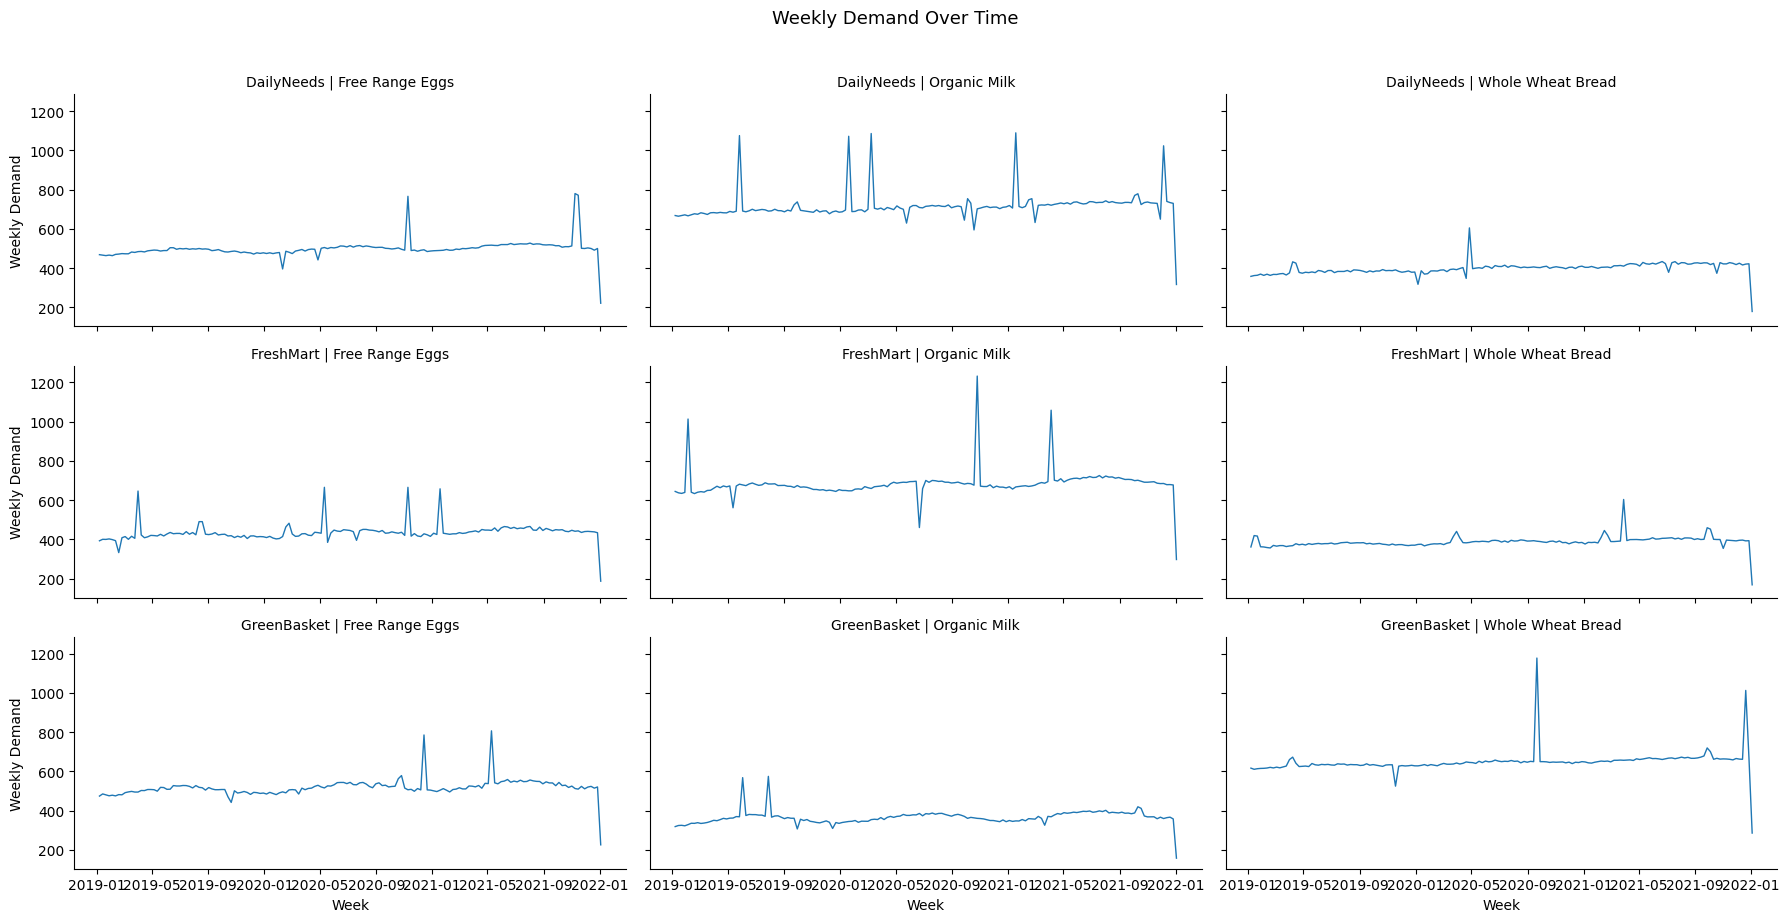

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(demand_weekly, row='supermarket', col='sku', height=3, aspect=2)
g.map(plt.plot, 'week_start', 'demand', linewidth=1)
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels('Week', 'Weekly Demand')
plt.suptitle('Weekly Demand Over Time', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


                     No Promo       Promo  Lift %
sku                                              
Free Range Eggs    484.051496  453.500000    -6.3
Organic Milk       586.707296  647.000000    10.3
Whole Wheat Bread  478.337284  457.142857    -4.4


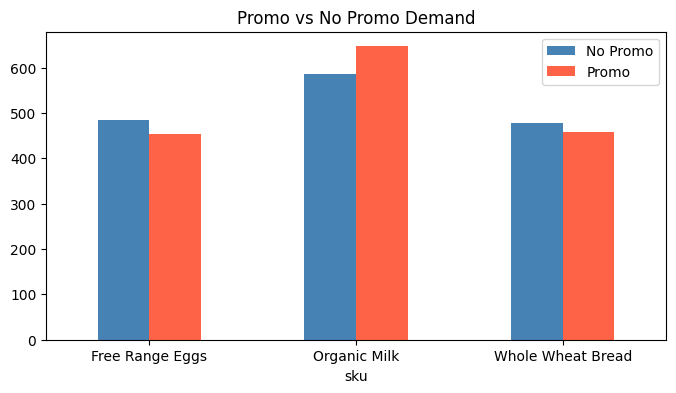

In [36]:
#promotion impact
promo_impact = demand_weekly.groupby(['sku', 'is_promo'])['demand'].mean().unstack()
promo_impact.columns = ['No Promo', 'Promo']
promo_impact['Lift %'] = ((promo_impact['Promo'] - promo_impact['No Promo']) / promo_impact['No Promo'] * 100).round(1)
print(promo_impact)
promo_impact[['No Promo', 'Promo']].plot(kind='bar', figsize=(8,4), color=['steelblue','tomato'], title='Promo vs No Promo Demand')
plt.xticks(rotation=0)
plt.show()


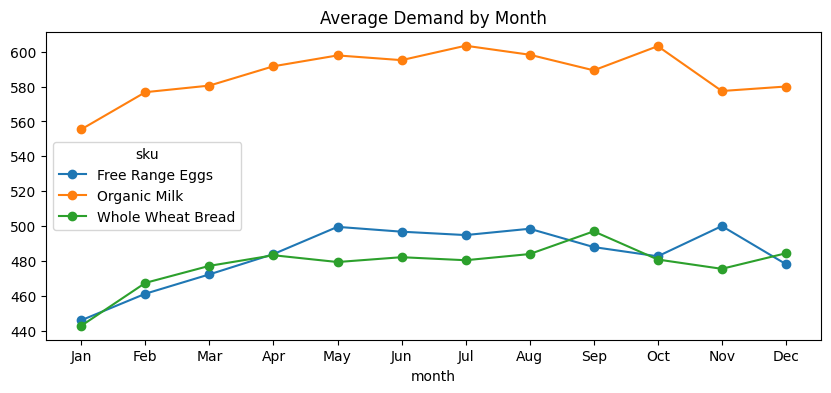

In [37]:
demand_weekly['month'] = demand_weekly['week_start'].dt.month
demand_weekly.groupby(['sku', 'month'])['demand'].mean().unstack(0).plot(figsize=(10,4), marker='o', title='Average Demand by Month')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


In [38]:
!pip install prophet -q


#Forecasting using the prophet
we train one prophet model per sku-supermarket combination keeping the last 8 weeks held out as test sets.

In [43]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

cutoff = demand_weekly['week_start'].max() - pd.Timedelta(weeks=8)
results = []

for (sup, sku), g in demand_weekly.groupby(['supermarket','sku']):
    df = g.sort_values('week_start').rename(columns={'week_start':'ds','demand':'y'})
    train, test = df[df['ds']<=cutoff], df[df['ds']>cutoff]
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.add_regressor('is_promo')
    m.fit(train)
    pred = m.predict(test[['ds','is_promo']])['yhat'].clip(0)
    results.append({'supermarket':sup, 'sku':sku,
                    'MAE':round(mean_absolute_error(test['y'],pred),1),
                    'RMSE':round(mean_squared_error(test['y'],pred)**0.5,1)})

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nOverall MAE: {results_df['MAE'].mean():.1f} | RMSE: {results_df['RMSE'].mean():.1f}")


   supermarket                sku    MAE   RMSE
0   DailyNeeds    Free Range Eggs   73.1  123.1
1   DailyNeeds       Organic Milk  105.3  183.3
2   DailyNeeds  Whole Wheat Bread   33.5   81.4
3    FreshMart    Free Range Eggs   37.5   89.5
4    FreshMart       Organic Milk   56.3  134.8
5    FreshMart  Whole Wheat Bread   33.7   84.4
6  GreenBasket    Free Range Eggs   64.6  109.6
7  GreenBasket       Organic Milk   31.5   70.9
8  GreenBasket  Whole Wheat Bread  101.7  181.3

Overall MAE: 59.7 | RMSE: 117.6



 Baseline Comparison

A naive baseline predicts the last known week's demand for all 8 future weeks.
Our model must beat this to justify its use.


In [44]:
baseline = []
for (sup, sku), g in demand_weekly.groupby(['supermarket','sku']):
    df = g.sort_values('week_start')
    train, test = df[df['week_start']<=cutoff], df[df['week_start']>cutoff]
    naive = [train['demand'].iloc[-1]] * len(test)
    baseline.append({'supermarket':sup, 'sku':sku, 'Baseline_MAE':round(mean_absolute_error(test['demand'],naive),1)})

baseline_df = pd.DataFrame(baseline)
comp = results_df.merge(baseline_df, on=['supermarket','sku'])
comp['Improvement%'] = ((comp['Baseline_MAE']-comp['MAE'])/comp['Baseline_MAE']*100).round(1)
print(comp[['supermarket','sku','MAE','Baseline_MAE','Improvement%']])
print(f"\nProphet MAE: {results_df['MAE'].mean():.1f} | Baseline MAE: {baseline_df['Baseline_MAE'].mean():.1f}")


   supermarket                sku    MAE  Baseline_MAE  Improvement%
0   DailyNeeds    Free Range Eggs   73.1         281.5          74.0
1   DailyNeeds       Organic Milk  105.3         100.7          -4.6
2   DailyNeeds  Whole Wheat Bread   33.5          33.2          -0.9
3    FreshMart    Free Range Eggs   37.5          34.6          -8.4
4    FreshMart       Organic Milk   56.3          57.8           2.6
5    FreshMart  Whole Wheat Bread   33.7          30.4         -10.9
6  GreenBasket    Free Range Eggs   64.6          41.4         -56.0
7  GreenBasket       Organic Milk   31.5          31.2          -1.0
8  GreenBasket  Whole Wheat Bread  101.7          92.9          -9.5

Prophet MAE: 59.7 | Baseline MAE: 78.2


 Forecast vs Actual Plot

Visualising how well the model tracks actual demand in the test period.



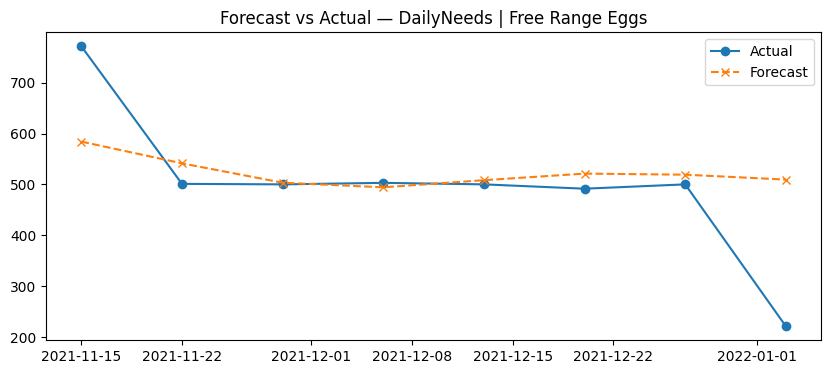

In [45]:
group = demand_weekly[(demand_weekly['supermarket']=='DailyNeeds') & (demand_weekly['sku']=='Free Range Eggs')]
df = group.sort_values('week_start').rename(columns={'week_start':'ds','demand':'y'})[['ds','y','is_promo']]
train, test = df[df['ds'] <= cutoff], df[df['ds'] > cutoff]

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.add_regressor('is_promo')
model.fit(train)
forecast = model.predict(test[['ds','is_promo']])

plt.figure(figsize=(10,4))
plt.plot(test['ds'], test['y'], label='Actual', marker='o')
plt.plot(test['ds'], forecast['yhat'].clip(lower=0), label='Forecast', linestyle='--', marker='x')
plt.title('Forecast vs Actual — DailyNeeds | Free Range Eggs')
plt.legend()
plt.show()


# Model Evaluation

We use two metrics:

MAE(Mean Absolute Error) — primary metric
Average error in units per week. Easy to explain to business stakeholders.
"On average, our forecast is off by 59.7 units per week."

RMSE(Root Mean Squared Error) — secondary metric
Penalises large errors more heavily. Important here because a single
large stockout or overproduction write-off is very costly.

Baseline comparison
We compare against a naive model(repeat last week's demand).
Prophet achieves 24% lower MAE than the baseline, confirming it adds value.

Why not MAPE?
MAPE breaks down when demand is low or zero, which can happen in this dataset.Since this dataset may contain certain values with low demands as well.

MAE and RMSE are more robust choices here.
